# Myllia - echoes of silenced genes
---

**authors**: [fsb2210](https://www.kaggle.com/fsb2210), [julianc93](https://www.kaggle.com/julianc93)

The task is to train a model that is able to predict *expression changes in scRNA-seq data induced by CRISPRi perturbations*. For that, we have a dataset of 80 different perturbations and the *average expression values* of genes, plus an unperturbed case (*non-targeting sgRNA*).

## Introduction

This problem esentially consists of inputs of strings given by the `pert_symbol` column and an output vector space of dimension equal to the number of columns minus the one corresponding to the `pert_symbol` (i.e., a 5127-dimensional space).

Clearly, this dataset needs to be preprocessed. In this notebook we describe the preprocessing steps taken.

### Preprocessing overview

Our start data comes from 4 external datasets, namely, *K562*, *HepG2*, *Jurkat* and *RPE1* (Replogle et al., Nadig et al.).

In order to have them in the same format as the training data provided in the challenge, we need to take the exact same steps as the ones described in the [*Normalization details*](https://www.kaggle.com/competitions/echoes-of-silenced-genes/data) section from the challenge:

* **Input data:** Raw UMI counts for the entire set of genes in the dataset.
* **Normalization:** Log-normalized counts applied uniformly across challenge and external datasets.
  $$
  x_{norm} = \log_2\left(\frac{x_{raw}}{\sum x_{raw}} \times 10,000 + 1\right)
  $$
* **Gene subset:** Data subsetted to the **5,127 target genes** relevant to the challenge.
* **Pseudo-Bulk (PB) aggregation:** Single-cell counts averaged per perturbation condition (arithmetic mean), disregarding batch information.

> NOTE: data from this notebook will be saved in the directory specified by the `interim_dir` variable. Each file will be prefix with the value of the variable `output_prefix`

In [1]:
import gc
import time
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.sparse as sp
import seaborn as sns

import scanpy as sc
from pdex import pdex

We define some auxiliary functions

In [2]:
# from here: https://davetang.org/muse/2024/11/14/ensembl-gene-ids-to-gene-symbols/
def parse_ensembl_map(path: str) -> pd.Series:
    """Parse the Ensembl v112 gene table into a Series"""
    df = pd.read_csv(path, sep="\t", header=None, usecols=[6, 7], names=["ensembl_id", "gene_name"], compression="gzip")
    df = df.dropna().drop_duplicates("ensembl_id")
    return df.set_index("ensembl_id")["gene_name"]

def resolve_gene_index(var: pd.DataFrame, genes: pd.Index, ensembl_map: pd.Series) -> pd.DataFrame:
    """Build a table that maps each gene to the integer column index it occupies in `adata.X` (if present)"""
    # lookup: gene_symbol -> integer position in var
    try:
        symbol_to_idx = pd.Series(np.arange(len(var)), index=var["gene_name"].values)
    except Exception:
        symbol_to_idx = pd.Series(np.arange(len(var)), index=var["features"].values)

    # Ensembl-based lookup using the v112 map
    var_ensembl_to_symbol = ensembl_map.reindex(var.index)   # ENSG -> v112 symbol
    ensembl_symbol_to_idx = pd.Series(np.arange(len(var)), index=var_ensembl_to_symbol.values).dropna()
    records = []
    for gene in genes:
        if gene in symbol_to_idx.index:
            records.append({"output_gene": gene, "var_idx": int(symbol_to_idx[gene])})
        elif gene in ensembl_symbol_to_idx.index:
            records.append({"output_gene": gene, "var_idx": int(ensembl_symbol_to_idx[gene])})
        else:
            records.append({"output_gene": gene, "var_idx": np.nan})

    result = pd.DataFrame(records)
    n_found = result["var_idx"].notna().sum()
    n_alias = sum(1 for g, r in zip(genes, records) if not pd.isna(r["var_idx"]) and g not in symbol_to_idx.index)
    print(f"  - direct symbol match: {n_found - n_alias}")
    print(f"  - Ensembl alias match: {n_alias}")
    print(f"  - absent: {result['var_idx'].isna().sum()}")
    return result

Define global options:

In [3]:
# directory with data files
data_dir = "../data"
raw_dir = "../data/raw"
interim_dir = "../data/interim"

# raw data filename
h5ad_fname = "training_cells.h5ad"

# train data filename
train_fname = "training_data_means.csv"

# Ensembl map
ensembl_map_fname = "hsapiens_gene_ensembl__gene__main.txt.gz"

# column name with target genes in var dataframe
gene_var_name = "sgrna_symbol"

# prefix for filenames to save as csv: expressions (data_means), delta expressions (deg), fdr (fdr)
output_prefix = "myllia"

# whether to save a list with the stratification strategy to be used when training a machine learning model
apply_stratification = True
stratification_fname = "../data/processed/stratify.csv"

## Data loading

We load the training dataset as well as the raw h5ad file from which we will create a processed dataset

In [4]:
# train & validation sets
train_df = pd.read_csv(f"{data_dir}/{train_fname}")
# raw h5ad data
raw = sc.read_h5ad(f"{raw_dir}/{h5ad_fname}")

Also load the map between Ensembl id and gene names

In [5]:
ensembl_map = parse_ensembl_map(f"{raw_dir}/{ensembl_map_fname}")

Will need these variables later on

In [6]:
target_genes = train_df.columns[1:]
perts = pd.Index(train_df["pert_symbol"].unique())

Let's filter genes by names to see how many of the `target_genes` are present in the raw h5ad file

In [7]:
gene_map = resolve_gene_index(raw.var, output_genes, ensembl_map)
present = gene_map.dropna(subset=["var_idx"])
var_idx = present["var_idx"].astype(int).values
# load only needed gene columns from disk
output_genes = present["output_gene"].values

  - direct symbol match: 5127
  - Ensembl alias match: 0
  - absent: 0


In [8]:
# change indices in the `raw.var` dataframe, it only fails with the training h5ad
try:
    raw.var.set_index(gene_var_name)
    raw.var_names = raw.var.gene_name.copy()
except KeyError:  # handle training case
    pass

## Data pre-processing

Now that we have the names of the genes acting as targets, we apply the normalization described earlier:

In [9]:
# use every gene to normalize
sc.pp.normalize_total(raw, target_sum=1e4)
sc.pp.log1p(raw, base=2)

# we only care about the target genes (target_genes)
raw_subset = raw[:, var_idx].copy()

# we don't need raw file anymore
del raw
gc.collect()

## Differential expression genes

Compute differential expressions as well as statistical tests between pertubed and basal states:

In [10]:
results = pdex(raw_subset, gene_var_name, is_log1p=False, geometric_mean=False, as_pandas=True)
results.rename(columns={"target": "pert_symbol"}, inplace=True)
results["deg"] = results["target_mean"] - results["ref_mean"]
results.drop(columns=["target_membership", "ref_membership", "fold_change", "percent_change", "p_value", "statistic"], inplace=True)

Running parallel differential expression (against reference): 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 81/81 [00:10<00:00,  8.06it/s]


Split results into different dataframes

In [11]:
exp = results.pivot(index="pert_symbol", columns="feature", values="target_mean")
deg = results.pivot(index="pert_symbol", columns="feature", values="deg")
fdr = results.pivot(index="pert_symbol", columns="feature", values="fdr")

To the dataframe with the results of the statistical tests (`fdr`), add a new column with the number of DEGs, defined to be those fdr values that are below a threshold of 0.05:

In [12]:
fdr["deg_count"] = fdr.apply(lambda x: (x < 0.05).sum(), axis=1)

We are now ready to save these files:

In [13]:
exp.to_csv(f"{interim_dir}/{output_prefix}_data_means.csv", index=False)
deg.to_csv(f"{interim_dir}/{output_prefix}_deg.csv", index=False)
fdr.to_csv(f"{interim_dir}/{output_prefix}_fdr.csv", index=False)

### Visualization of DEGs

We can visualize the number of DEGs that each perturbation produces as a barplot

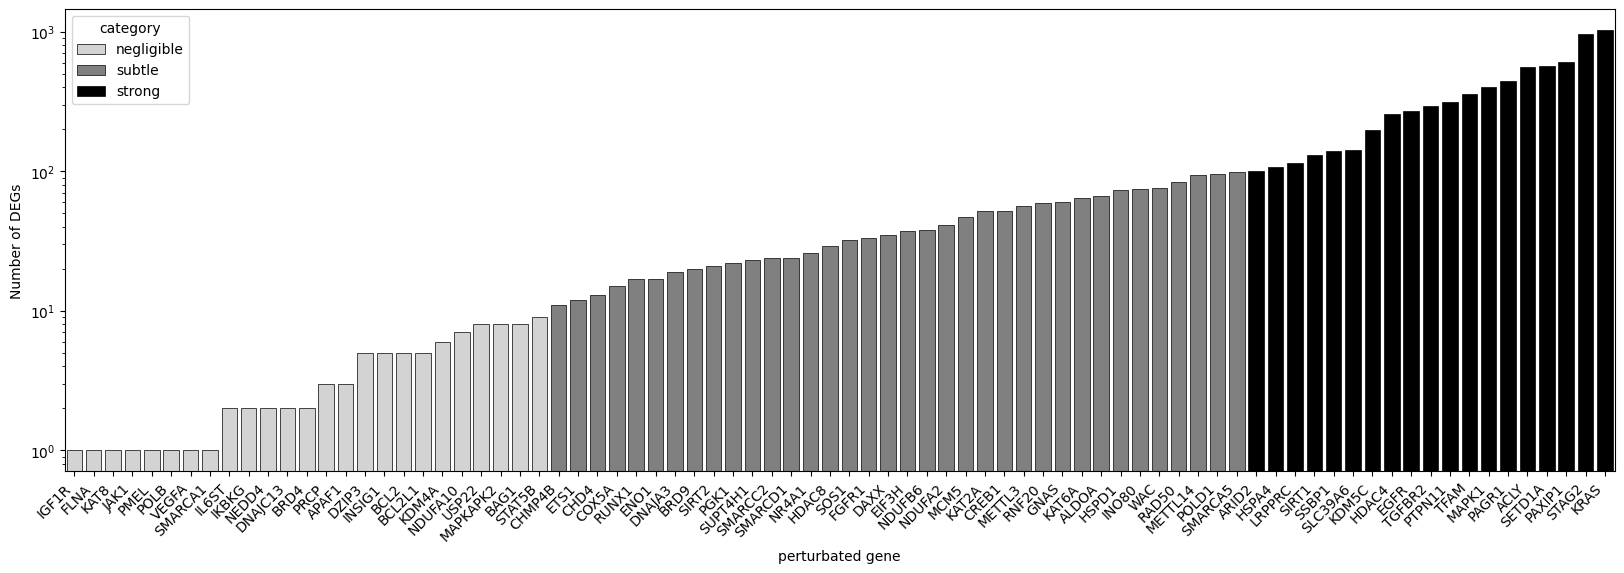

In [14]:
# create dataframe and sort ascending
fdr_df = pd.DataFrame({
    "perturbation": fdr.index, 
    "deg_count": fdr["deg_count"].values,
}).sort_values("deg_count", ascending=True).reset_index(drop=True)

fdr_df["category"] = np.where(fdr_df["deg_count"] < 10, "negligible", np.where(fdr_df["deg_count"] < 100, "subtle", "strong"))

# Custom colors: lightgray (negligible), orange (subtle), darkred (strong)
color_map = {"negligible": "lightgray", "subtle": "gray", "strong": "black"}

# Bar plot (horizontal for better readability with many perturbations)
plt.figure(figsize=(20, 6))
sns.barplot(data=fdr_df, x="perturbation", y="deg_count", hue="category", palette=color_map, edgecolor="black", linewidth=0.5)
plt.xticks(rotation=45, ha="right")
plt.yscale("log")
plt.ylabel("Number of DEGs")
plt.xlabel("perturbated gene");

In [15]:
print(f"- negligible perturbations (< 10 DEGs): {np.sum(fdr_df["deg_count"] < 10)}")
print(f"- subtle perturbations (< 100 DEGs): {fdr_df.shape[0] - (np.sum(fdr_df["deg_count"] < 10) + np.sum(fdr_df["deg_count"] > 100))}")
print(f"- strong perturbations: {np.sum(fdr_df["deg_count"] > 100)}")

- negligible perturbations (< 10 DEGs): 25
- subtle perturbations (< 100 DEGs): 37
- strong perturbations: 18


### Stratify training using DEGs result

Using the fact that there are three distinct classes of perturbations, as seen above, we can use such information to our advantage when training a machine learning model that predicts DEGs

In [16]:
def classify(x):
    total = x["deg_count"]
    if total < 10: return 0
    if total < 100: return 1
    return 2

if apply_stratification:
    fdr_df["type"] = fdr_df.apply(classify, axis=1)
    stratify = fdr_df.copy()
    stratify.drop(columns=["category", "deg_count"], inplace=True)
    stratify.rename(columns={"perturbation": "pert_symbol"}, inplace=True)
    stratify.to_csv(stratification_fname, index=False)
    # convert perturbation column to Categorical with the same order as the train_df
    stratify["pert_symbol"] = pd.Categorical(stratify["pert_symbol"], categories=train_df.pert_symbol.tolist()[:-1], ordered=True)
    stratify = stratify.sort_values("pert_symbol").reset_index(drop=True)